In [17]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from pathlib import Path
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.optim as optim

In [18]:
if torch.cuda.is_available():
    print("Cuda ok")

Cuda ok


# Globals

In [ ]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_SIZE = 0.8
BATCH_SIZE = 32

EMBEDDING_DIM = 256
EMBEDDING_FOURIER_DIM = 64
EMBEDDING_RGB_DIM = 64
WEIGHT_TASK = 0.5
LEARNING_RATE = 1e-4
EPOCHS = 50
DEVICE = "cuda"

# Utils

In [20]:
def model_info(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Calcolo in MB (assumendo float32)
    size_in_mb = total_params * 4 / (1024 ** 2)
    
    # Uso i due punti e la virgola (:,) per mettere i separatori delle migliaia
    print(f"Parametri Totali:       {total_params:,}")
    print(f"Parametri Addestrabili: {trainable_params:,}")
    print(f"Dimensione (float32):   {size_in_mb:.2f} MB")
    
    return total_params, trainable_params, size_in_mb

def train_multitask_model(model, train_loader, val_loader, epochs= EPOCHS, learning_rate= LEARNING_RATE, device=None, weight_task= WEIGHT_TASK):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)
    print(next(model.parameters()).device)
    # Loss definition
    criterion_ai = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        
        train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}] - Train")
        for images, labels in train_loop:
            # Move the samples on the devide (GPU or CPU)
            images = images.to(device)
            label_ai = labels['label_ai'].to(device)
            label_domain = labels['label_domain'].to(device)

            optimizer.zero_grad()

            # Forward Pass: get the tasks logits
            logits_binary, logits_transform = model(images)

            # Compute the loss functions
            loss_ai = criterion_ai(logits_binary, label_ai)
            loss_domain = criterion_domain(logits_transform, label_domain)

            # Combine the losses
            total_loss = loss_ai*weight_task + loss_domain*(1-weight_task)

            # Backward Pass and parameters update
            total_loss.backward()
            optimizer.step()

            running_train_loss += total_loss.item()
            
            # Update the progress bar
            train_loop.set_postfix(loss=total_loss.item())
            
        avg_train_loss = running_train_loss / len(train_loader)
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        correct_ai = 0
        correct_domain = 0
        total_samples = 0
        
        # Disabilita il calcolo dei gradienti per risparmiare memoria e velocizzare
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{epochs}] - Val  ", leave=False)
            
            for images, labels in val_loop:
                images = images.to(device)
                label_ai = labels['label_ai'].to(device)
                label_domain = labels['label_domain'].to(device)
                
                # Forward Pass
                logits_binary, logits_transform = model(images)
                
                # Compute the loss functions
                loss_ai = criterion_ai(logits_binary, label_ai)
                loss_domain = criterion_domain(logits_transform, label_domain)

                total_loss = loss_ai*weight_task + loss_domain*(1-weight_task)
                running_val_loss += total_loss.item()
                
                # Accuracy: prendiamo l'indice con il valore massimo (argmax)
                _, preds_ai = torch.max(logits_binary, dim=1)
                _, preds_domain = torch.max(logits_transform, dim=1)
                
                total_samples += images.size(0)
                correct_ai += (preds_ai == label_ai).sum().item()
                correct_domain += (preds_domain == label_domain).sum().item()
                
        avg_val_loss = running_val_loss / len(val_loader)
        acc_ai = correct_ai / total_samples
        acc_domain = correct_domain / total_samples
        
        print(f"\n--- Epoch {epoch+1} ---")
        print(f"Training Loss:   {avg_train_loss:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}")
        print(f"Val Accuracy AI: {acc_ai * 100:.2f}% | Val Accuracy Domain: {acc_domain * 100:.2f}%\n")
        
    print("Training Completed")
    return None

# Data

In [21]:
class RRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        
        self.class_ai_to_idx = {"real": 0, "ai": 1}
        self.class_domain_to_idx = {"original": 0, "redigital": 1, "transfer": 2}

        for domain in self.class_domain_to_idx.keys():
            domain_path = self.root_dir / domain
            if not domain_path.exists(): continue
                
            for class_name in self.class_ai_to_idx.keys():
                class_path = domain_path / class_name
                for pattern in ("*.jpg", "*.png"):
                    for img_path in class_path.glob(pattern):
                        self.samples.append((img_path, self.class_ai_to_idx[class_name], self.class_domain_to_idx[domain]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_ai, label_domain = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, {
            'label_ai': torch.tensor(label_ai, dtype=torch.long),
            'label_domain': torch.tensor(label_domain, dtype=torch.long)
        }

my_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = RRDataset(root_dir=Path(".")/"RRDataset_test"/"RRDataset_final", transform=my_transforms)

In [22]:
dataset_size = len(dataset)
train_size = int(TRAIN_SIZE * dataset_size)
val_size = dataset_size - train_size

# Split
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

# DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size= BATCH_SIZE, 
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset, 
    batch_size= BATCH_SIZE, 
    shuffle=False
)

print(f"Dataset Total size: {dataset_size}")
print(f"Training Set size: {len(train_dataset)}")
print(f"Validation Set size: {len(val_dataset)}")

Dataset Total size: 50980
Training Set size: 40784
Validation Set size: 10196


# Network

## FourierNet


In [23]:
class FourierNetInput(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x_fft = torch.fft.fft2(x)
        x_fft_shifted = torch.fft.fftshift(x_fft)
        x_mag = torch.abs(x_fft_shifted)
        x_phase = torch.angle(x_fft_shifted)
        x_mag = torch.log(x_mag + 1) # Use the log in order to enphasise the differences between the magnitude values of each pixel
        return x_mag, x_phase

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.64].


torch.Size([32, 3, 224, 224])


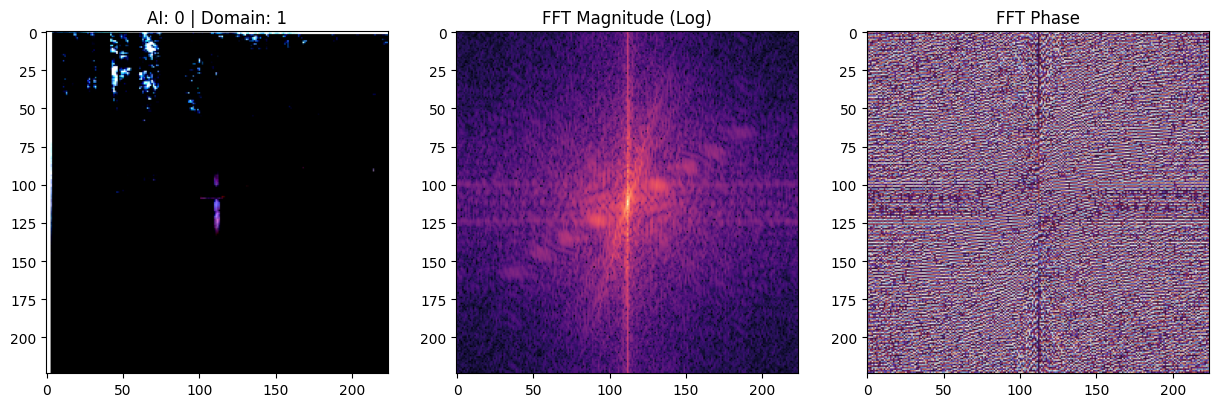

In [24]:
model = FourierNetInput()
images, labels = next(iter(train_loader))
mag, phase = model(images)

index = 0
print(images.shape)
img_to_show = images[index]
mag_to_show = mag[index]
phs_to_show = phase[index]

img_display = img_to_show.permute(1, 2, 0)
mag_display = mag_to_show[0] # show only the first channel of the magnitude 
phs_display = torch.mean(phs_to_show, dim=0)

label_ai_val = labels['label_ai'][index].item()
label_dom_val = labels['label_domain'][index].item()

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img_display)
plt.title(f"AI: {label_ai_val} | Domain: {label_dom_val}")

# Magnitude
plt.subplot(1, 3, 2)
plt.imshow(mag_display, cmap='magma')
plt.title("FFT Magnitude (Log)")

# Phase
plt.subplot(1, 3, 3)
plt.imshow(phs_display, cmap='twilight')
plt.title("FFT Phase")

plt.show()

## BackBone

### FourierNet

In [25]:
class FourierNet(nn.Module):
    def __init__(self, feature_dim=EMBEDDING_FOURIER_DIM):
        super().__init__()

        self.fourier_transform = FourierNetInput()
        
        # 6 input channels: 3 for the magnitude + 3 for the phase
        self.layers = nn.Sequential(
            self._make_layer(6, 32),  # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # each channel in input is summarized in a tensor of 1x1, namely a single value -> [B, 128, 1, 1]
        
        # Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(128, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # zero padding (default of padding=1) -> output layer has the same dimension of the input
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # halve the spatial dimension of the input layer H/2, W/2
        )
        
    def forward(self, x):
        # Fourier Transform
        mag, phase = self.fourier_transform(x)
        
        # Concatenation of the magnitude and the phase along the first dimension (channels) 
        x_f = torch.cat((mag, phase), dim=1) # Shape: [B, 6, H, W]
        
        # Convolutional layers
        x_f = self.layers(x_f)
        
        # Embedding extraction
        x_f = self.global_pool(x_f)
        x_f = torch.flatten(x_f, 1)  # Output: [B, 128]
        
        embedding = self.fc_embedding(x_f) # Output: [B, EMBEDDING_FOURIER_DIM]

        return embedding

### RGBNet

In [26]:
class RGBNet(nn.Module):
    def __init__(self, feature_dim= EMBEDDING_RGB_DIM):
        super().__init__()
        
        # Convolutional Architecture
        self.layers = nn.Sequential(
            self._make_layer(3, 32),   # Output: [B, 32, H/2, W/2]
            self._make_layer(32, 64), # Output: [B, 64, H/4, W/4]
            self._make_layer(64, 128) # Output: [B, 128, H/8, W/8]
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1)) # Output: [B, 128, 1, 1]
        
        # Fully Connected to obtain the informative vector (embedding)
        self.fc_embedding = nn.Sequential(
            nn.Linear(128, feature_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )

    def _make_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.layers(x)
        
        # Pooling and Flattening
        x = self.global_pool(x)
        x = torch.flatten(x, 1) # Output: [B, 128]
        
        # Embedding extraction
        embedding = self.fc_embedding(x) # Output: [B, EMBEDDING_RGB_DIM]
        
        return embedding

### Merged

In [27]:
class BackBone(nn.Module):
    def __init__(self, final_embedding_dim= EMBEDDING_DIM):
        super().__init__()
        
        self.fourier_net = FourierNet()
        self.rgb_net = RGBNet()

        feature_dim = EMBEDDING_FOURIER_DIM + EMBEDDING_RGB_DIM
        self.fc_embedding = nn.Sequential(
            nn.Linear(feature_dim, final_embedding_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x_f = self.fourier_net(x) # Output [B, feature_dim/2]
        x_rgb = self.rgb_net(x)   # Output [B, feature_dim/2]

        x_c = torch.cat((x_f, x_rgb), dim= 1) # Output [B, feature_dim]

        # Final embedding
        embedding = self.fc_embedding(x_c) # Output [B, EMBEDDING_DIM]

        return embedding

## Two-head Architecture

In [28]:
class BinaryClassifier(nn.Module):
    def __init__(self, embedding_dim: int = EMBEDDING_DIM, hidden_dim: int = 128, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)


class TransformClassifier(nn.Module):
    def __init__(self, embedding_dim: int = EMBEDDING_DIM, hidden_dim: int = 128, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3)
        )

    def forward(self, x):
        return self.net(x)


class MultiHeadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.binary_head = BinaryClassifier()
        self.transform_head = TransformClassifier()

    def forward(self, emb_fused):
        logits_binary = self.binary_head(emb_fused)
        logits_transform = self.transform_head(emb_fused)
        return logits_binary, logits_transform

## Final Model

In [29]:
class MultiTaskNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.backbone = BackBone()
        self.multi_head = MultiHeadModel()

    def forward(self, x):
        x_emb = self.backbone(x)
        logits_binary, logits_transform = self.multi_head(x_emb)

        return logits_binary, logits_transform


# Training

In [30]:
model = MultiTaskNet()
model_info(model)

Parametri Totali:       305,253
Parametri Addestrabili: 305,253
Dimensione (float32):   1.16 MB


(305253, 305253, 1.1644477844238281)

In [31]:
train_multitask_model(model, 
                      train_loader,
                      val_loader,
                      device= DEVICE)

cuda:0


Epoch [1/50] - Train:   2%|▏         | 28/1275 [00:12<09:24,  2.21it/s, loss=0.869]


KeyboardInterrupt: 